# **Computational Drug Discovery Exploratory Data Analysis** [2nd Lesson]

Dr. Rameez Hassan

---

# ** What is EDA (Exploratory Data Analysis)?

Exploratory Data Analysis (EDA) is the process of understanding your data before building any machine learning model.

In simple words:

EDA is like getting to know your data before trusting it with AI.

Before we train a QSAR or ML model, we ask:

What does the data look like?

Is it clean?

Is it balanced?

Does it make chemical and biological sense?

EDA helps us answer these questions.

# ** EDA explained with a simple analogy

Imagine you are a doctor and the data is your patient.

You would never prescribe medicine:

without checking vitals,

without seeing the lab reports,

without understanding the history.

👉 EDA is the “medical checkup” of your dataset
before we apply machine learning.

# ** What is RDKit?

RDKit is an open-source cheminformatics library used in:

QSAR modeling

Molecular descriptor calculation

Fingerprints (ECFP, Morgan)

SMILES handling

Molecular visualization and featurization

👉 In ML-based QSAR and AI-driven drug discovery, RDKit is essential because:

Machine learning models cannot read molecules directly

RDKit converts chemical structures into numerical features that ML models can learn from

# ** What is Conda?

Conda is a package and environment manager, widely used in:

Data science

Bioinformatics

Cheminformatics

It is especially important because:

RDKit has complex dependencies (C++, chemistry toolkits)

Normal pip install often fails or breaks

👉 Conda provides a stable environment where RDKit can work properly.

# ** Why are we installing Miniconda instead of full Anaconda?

Miniconda is a lightweight version of Conda

It installs only what is needed

Ideal for cloud notebooks (Colab, Kaggle, JupyterHub)

# ** What is this code doing? (Step-by-step, briefly)
🔹 1. Download Miniconda installer

🔹 2. Make installer executable

## **Install conda and rdkit**

What is this code doing? (Step-by-step, briefly)
🔹 1. Download Miniconda installer

In [1]:
!pip install -q rdkit


In [ ]:
import os
os._exit(0)


In [2]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

mol = Chem.MolFromSmiles("CCO")
print("Molecular weight:", Descriptors.MolWt(mol))


Molecular weight: 46.069


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski


In [4]:
# Remove previous miniconda installation if it exists at /usr/local
! rm -rf /usr/local/conda /usr/local/bin/conda /usr/local/etc/profile.d/conda.sh

# Install Mambaforge for a modern Conda environment
# This installs a Python version compatible with the Mambaforge release and handles dependencies.
# Corrected URL to a specific valid release version (24.3.0-0) as 'latest' was pointing to an invalid one.
! wget "https://github.com/conda-forge/miniforge/releases/download/24.3.0-0/Mambaforge-Linux-x86_64.sh" -O mambaforge.sh
! bash mambaforge.sh -b -p /usr/local

# Initialize Conda/Mamba for the current session
# This ensures that 'conda' and 'mamba' commands are available and the environment is correctly set up.
import os
os.environ["PATH"] = "/usr/local/bin:" + os.environ["PATH"]

# Install rdkit from conda-forge using mamba
# conda-forge is known for good dependency management, especially for rdkit, ensuring numpy compatibility.
! mamba install -y -c conda-forge rdkit

# No need to append sys.path manually as mamba sets up the environment correctly.

--2026-01-26 18:44:02--  https://github.com/conda-forge/miniforge/releases/download/24.3.0-0/Mambaforge-Linux-x86_64.sh
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/221584272/0cb2568c-01fe-48f6-9599-2b71d9b7f72f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-26T19%3A30%3A15Z&rscd=attachment%3B+filename%3DMambaforge-Linux-x86_64.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-26T18%3A29%3A57Z&ske=2026-01-26T19%3A30%3A15Z&sks=b&skv=2018-11-09&sig=%2FZif905bHYirZLggejHmcAqRRxxHelTAaLf4GzHlLc8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2OTQ1NDg0MiwibmJmIjoxNzY5NDUzMDQyLCJwYXRoIjoicmVsZW

## **Load bioactivity data**

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('bioactivity_curated.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [7]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

* **Purpose of the code:** Convert chemical structures (SMILES) into numerical **Lipinski descriptors**, which are required for QSAR modeling and machine learning in drug discovery.
* **Input handling:** The function takes a list or column of SMILES strings and processes them one by one.
* **SMILES to molecules:** Each SMILES string is converted into an **RDKit molecule object**, because ML models cannot work directly with chemical text.
* **Descriptor calculation:** From these molecule objects, **Lipinski-related physicochemical properties** (e.g., molecular weight, lipophilicity, hydrogen bond features) are computed.
* **Tabular representation:** The calculated descriptors are stored in a **pandas DataFrame**, where rows represent compounds and columns represent descriptors.
* **Output for ML:** The function returns this DataFrame, which becomes a **QSAR-ready feature set**.
* **Practical use:** Applying the function to `df.canonical_smiles` generates `df_lipinski`, forming the basis for downstream **ML-based QSAR and AI-driven drug discovery models**.


### **Calculate descriptors**

In [8]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [9]:
df_lipinski = lipinski(df.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [10]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,312.325,2.8032,0.0,6.0
1,376.913,4.5546,0.0,5.0
2,426.851,5.3574,0.0,5.0
3,404.845,4.7069,0.0,5.0
4,346.334,3.0953,0.0,6.0
...,...,...,...,...
6893,485.410,3.9041,2.0,4.0
6894,378.944,4.8830,2.0,4.0
6895,406.998,5.5761,1.0,4.0
6896,424.988,5.5257,1.0,4.0


In [11]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0,active


Now, let's combine the 2 DataFrame

In [12]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [13]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active,312.325,2.8032,0.0,6.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active,376.913,4.5546,0.0,5.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive,426.851,5.3574,0.0,5.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active,404.845,4.7069,0.0,5.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active,346.334,3.0953,0.0,6.0
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0,intermediate,485.410,3.9041,2.0,4.0
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0,active,378.944,4.8830,2.0,4.0
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0,active,406.998,5.5761,1.0,4.0
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0,active,424.988,5.5257,1.0,4.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [14]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        if molar == 0:
            pIC50.append(10.0) # Assign a high pIC50 for 0 nM values
        else:
            pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [15]:
df_combined.standard_value.describe()

,standard_value
count,6.898000e+03
mean,9.923881e+04
std,8.720039e+05
min,0.000000e+00
25%,1.600000e+02
50%,2.420000e+03
75%,1.626500e+04
max,4.960000e+07


In [16]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [17]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [18]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [19]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,6.0,750.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,5.0,100.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,5.0,50000.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,5.0,300.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,6.0,800.0
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.410,3.9041,2.0,4.0,5090.0
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.944,4.8830,2.0,4.0,411.0
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,406.998,5.5761,1.0,4.0,395.0
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.988,5.5257,1.0,4.0,625.0


In [20]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,6.898000e+03
mean,9.923881e+04
std,8.720039e+05
min,0.000000e+00
25%,1.600000e+02
50%,2.420000e+03
75%,1.626500e+04
max,4.960000e+07


In [21]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,6.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,5.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,5.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,5.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,6.0,6.096910
...,...,...,...,...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,intermediate,485.410,3.9041,2.0,4.0,5.293282
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.944,4.8830,2.0,4.0,6.386158
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,406.998,5.5761,1.0,4.0,6.403403
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.988,5.5257,1.0,4.0,6.204120


In [22]:
df_final.pIC50.describe()

,pIC50
count,6898.000000
mean,5.815517
std,1.553852
min,1.304518
25%,4.788746
50%,5.616185
75%,6.795880
max,14.301030


In [27]:
df_final.to_csv('acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv')


### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [28]:
df_2class = df_final[df_final['class'] != 'intermediate'].copy()
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,312.325,2.8032,0.0,6.0,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,376.913,4.5546,0.0,5.0,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,426.851,5.3574,0.0,5.0,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,404.845,4.7069,0.0,5.0,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,346.334,3.0953,0.0,6.0,6.096910
...,...,...,...,...,...,...,...,...
6890,CHEMBL6040839,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,484.422,5.1372,1.0,4.0,6.517126
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,378.944,4.8830,2.0,4.0,6.386158
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,406.998,5.5761,1.0,4.0,6.403403
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,424.988,5.5257,1.0,4.0,6.204120


In [29]:
df_2class.to_csv('acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv')


---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [30]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

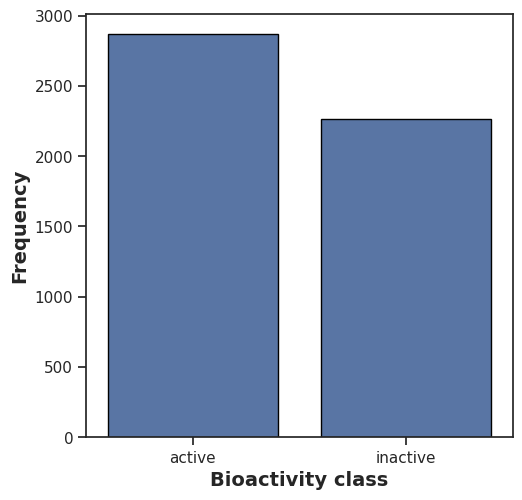

In [31]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

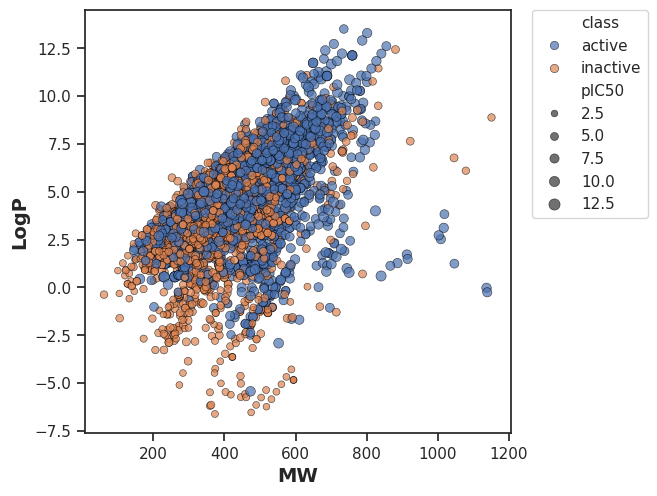

In [32]:
plt.figure(figsize=(5.5, 5.5))

# Replace any infinite values in 'pIC50' with 10.0 to ensure all values are finite for plotting
df_2class['pIC50'] = df_2class['pIC50'].replace([np.inf, -np.inf], 10.0)

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

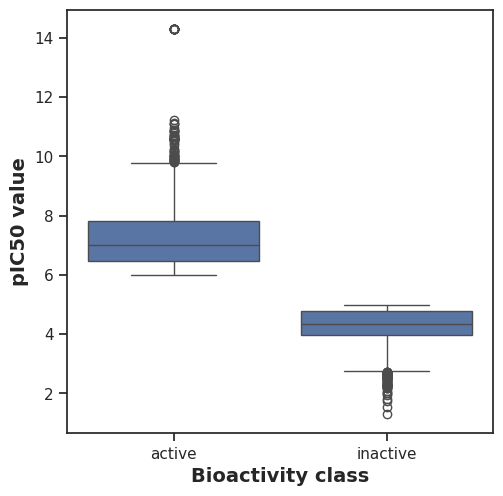

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [34]:
def mannwhitney(descriptor, verbose=False):
  from numpy.random import seed
  from scipy.stats import mannwhitneyu
  import pandas as pd
  import numpy as np

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df_filtered = df_2class[selection].copy() # Use .copy() to avoid SettingWithCopyWarning

  active_group = df_filtered[df_filtered['class'] == 'active'][descriptor].dropna()
  inactive_group = df_filtered[df_filtered['class'] == 'inactive'][descriptor].dropna()

  stat = np.nan
  p = np.nan
  interpretation = 'Cannot perform test (one or both groups are empty or contain only NaN values)'

  if not active_group.empty and not inactive_group.empty:
      if active_group.nunique() > 1 and inactive_group.nunique() > 1: # Ensure enough unique values for a meaningful test
          stat, p = mannwhitneyu(active_group, inactive_group)
          alpha = 0.05
          if np.isnan(p):
              interpretation = 'Cannot perform test (p-value is NaN)'
          elif p > alpha:
              interpretation = 'Same distribution (fail to reject H0)'
          else:
              interpretation = 'Different distribution (reject H0)'
      else:
          interpretation = 'Cannot perform test (insufficient unique values in one or both groups)'
  else:
      interpretation = 'Cannot perform test (one or both groups are empty)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':0.05, # Always use 0.05 for alpha in the results dataframe
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [35]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,6500550.0,0.0,0.05,Different distribution (reject H0)


#### **MW**

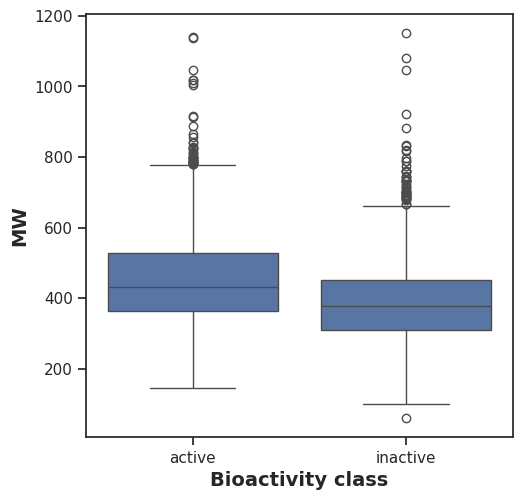

In [36]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [37]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,4193476.0,1.639718e-71,0.05,Different distribution (reject H0)


#### **LogP**

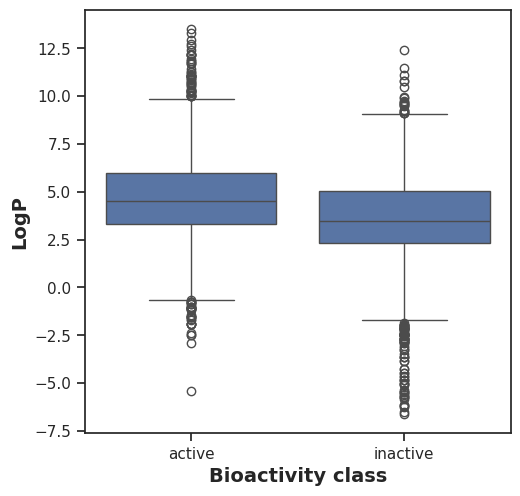

In [38]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [39]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,4144320.5,1.933818e-64,0.05,Different distribution (reject H0)


#### **NumHDonors**

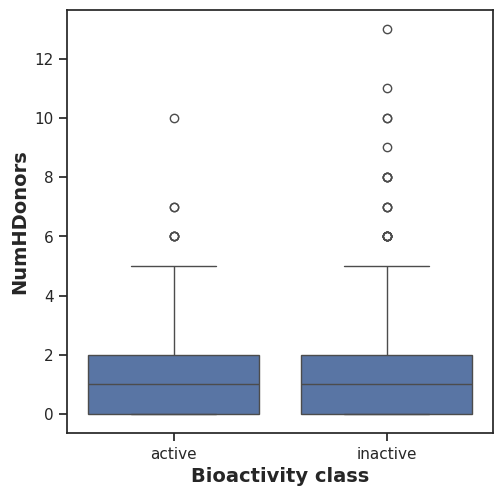

In [40]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [41]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3695561.5,8.829861e-19,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

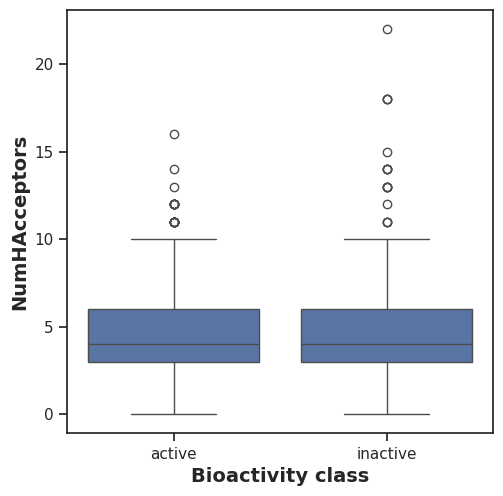

In [42]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [43]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,3509179.0,6.260853e-07,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [44]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_MW_vs_LogP.pdf (deflated 2%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: plot_MW.pdf (deflated 38%)
  adding: acetylcholinesterase_05_bioactivity_data_2class_pIC50.csv (deflated 75%)
  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 11%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: plot_ic50.pdf (deflated 35%)
  adding: bioactivity_curated.csv (deflated 82%)
  adding: mannwhitneyu_pIC50.csv (deflated 11%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: acetylcholinesterase_04_bioactivity_data_3class_pIC50.csv (deflated 76%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
